In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint
import functools
from pathlib import Path

import hydra
import duckdb
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches
import seaborn as sns
font_scale = 7
sns.set_theme(style='whitegrid', font_scale=font_scale, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import torch

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [4]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

# Run queries

### Datasets

In [5]:
dataset_cols = """
    Dataset.id,
    time_step_count,
    time_step_count_drop_first,
    observe_every_n_time_steps,
"""

##### Lorenz '96

In [317]:
dataset_name = "Lorenz96"
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join Lorenz96 on Dataset.id = Lorenz96.id
    where true
    and state_dimension = 1e6
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
""")
assert len(dataset_rows) == 1
dataset_multiple = 1

##### Kuramoto-Sivashinsky

In [352]:
dataset_name = 'KuramotoSivashinsky'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join KuramotoSivashinsky on Dataset.id = KuramotoSivashinsky.id
    join ATan on Dataset.Observe = ATan.id
    where true
    and state_dimension = 1024
    and floating_point_precision = 32
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
    and predicted_state_count = 20
""")
assert len(dataset_rows) == 1
dataset_multiple = 1

##### Navier-Stokes ($64 \times 64$)

In [393]:
dataset_name = 'NavierStokesDim64'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join NavierStokes on Dataset.id = NavierStokes.id
    join ATan on Dataset.Observe = ATan.id
    where true
    and state_dimension = 3*64*64
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
    and predicted_state_count = 20
""")
assert len(dataset_rows) == 1
dataset_multiple = 1

##### Navier-Stokes ($256 \times 256$)

In [428]:
dataset_name = 'NavierStokesDim256'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join NavierStokes on Dataset.id = NavierStokes.id
    where true
    and state_dimension = 3*256*256
    and time_step_count = 6000
    and time_step_size = 1e-4
    and observe_every_n_time_steps = 100
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
""")
assert len(dataset_rows) == 1
dataset_multiple = 1

### Models

##### EnSF

In [429]:
var1, var1_latex = 'epsilon_beta', r'$\epsilon_{\beta}$'
var2, var2_latex = 'epsilon_alpha', r'$\epsilon_{\alpha}$'
label = 'EnSF'
model_name = 'ScoreMatchingMarginal'
sampling_time_step_count = 10
model_rows = duckdb.sql(f"""
    select
        Model.id,
        {label!r},
        epsilon_alpha,
        epsilon_beta,
        sampling_time_step_count,
    from Model
    join ScoreMatchingMarginal on Model.id = ScoreMatchingMarginal.id
    join Bao2024EnsembleScoreMatching on ScoreMatchingMarginal.DiffusionPath = Bao2024EnsembleScoreMatching.id
    where true
    and sampling_time_step_count = {sampling_time_step_count}
    and epsilon_alpha in (0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0)
    and epsilon_beta in (1e-3,5e-3,0.025,0.075,0.125,0.175,0.225,0.275)
""")
model_multiple = (
    10  # epsilon_alpha
    * 8  # epsilon_beta
)

##### EnFF-OT

In [440]:
var1, var1_latex = 'sigma_min', r'$\sigma_{\min}$'
var2, var2_latex = 'lambda', r'$\lambda$'
label = 'EnFF-OT'
model_name = 'FlowMatchingMarginalConditionalOptimalTransport'
sampling_time_step_count = 10
model_rows = duckdb.sql(f"""
    select
        Model.id,
        {label!r},
        sigma_min,
        constant as lambda,
        sampling_time_step_count,
    from Model
    join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id
    join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id
    join Local on FlowMatchingMarginal.EnergyGuidance = Local.id
    join Constant on Local.Schedule = Constant.id
    where true
    and sampling_time_step_count = {sampling_time_step_count}
    and sigma_min in (1e-5, 1e-4, 1e-3, 1e-2, 1e-1)
    and constant in (1e-3, 5e-3, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0)
""")
model_multiple = (
    5  # sigma_min
    * 13  # constant as lambda
)

##### EnFF-F2P

In [451]:
var1, var1_latex = 'sigma_min', r'$\sigma_{\min}$'
var2, var2_latex = 'lambda', r'$\lambda$'
label = 'EnFF-F2P'
model_name = 'FlowMatchingMarginalPreviousPosteriorToPredictive'
sampling_time_step_count = 10
model_rows = duckdb.sql(f"""
    select
        Model.id,
        {label!r},
        sigma_min,
        constant as lambda,
        sampling_time_step_count,
    from Model
    join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id
    join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id
    join Local on FlowMatchingMarginal.EnergyGuidance = Local.id
    join Constant on Local.Schedule = Constant.id
    where true
    and sampling_time_step_count = {sampling_time_step_count}
    and sigma_min in (1e-5, 1e-4, 1e-3, 1e-2, 1e-1)
    and constant in (1e-3, 5e-3, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0)
""")
model_multiple = (
    5  # sigma_min
    * 13  # constant as lambda
)

### General

In [452]:
rows = duckdb.sql(f"""
    select alt_id, model_rows.*, dataset_rows.*
    from Conf
    join dataset_rows on Conf.Dataset = dataset_rows.id
    join model_rows on Conf.Model = model_rows.id
    where true
    and rng_seed = 2376999025
""").pl()
assert len(rows) == dataset_multiple * model_multiple, f'{len(rows) = } != {dataset_multiple * model_multiple}'

In [453]:
filepaths = duckdb.sql("""
select format('~/out/dafm/runs/{}/dataset_metrics.csv', alt_id) as filepath from rows
""").pl()
filepath_exists = []
for f in filepaths.get_column('filepath'):
    f = Path(f).expanduser()
    exists = f.exists()
    if not exists:
        print(f"File path does not exist: '{f}'")
    filepath_exists.append(exists)
filepaths = pl.DataFrame(dict(filepath=filepaths.get_column('filepath'), exists=filepath_exists))
assert filepaths['exists'].any()
duckdb.sql("""
set variable dataset_metrics_filepaths = (
    select list(filepath) from filepaths where exists
)
""")

In [454]:
observation_steps_back = 50
logged_metrics = duckdb.sql(f"""
    select rows.*, logs.*,
    from (
        select split(filename, '/')[-2] as alt_id, step, time_s, crps, rmse,
        from read_csv(getvariable(dataset_metrics_filepaths), filename=true, union_by_name=true)
    ) as logs
    join rows on rows.alt_id = logs.alt_id
    where true
    and (logs.step - time_step_count_drop_first - 1) % observe_every_n_time_steps == 0 -- include only analysis time steps
    and step > time_step_count - observe_every_n_time_steps * {observation_steps_back}
""").pl()
logged_metrics

alt_id,id,'EnFF-F2P',sigma_min,lambda,sampling_time_step_count,id_1,time_step_count,time_step_count_drop_first,observe_every_n_time_steps,alt_id_1,step,time_s,crps,rmse
str,i64,str,f64,f64,i64,i64,i64,i64,i64,str,i64,f64,f64,f64
"""epab6r74""",787,"""EnFF-F2P""",0.1,0.001,10,85,6000,0,100,"""epab6r74""",1001,0.244773,21.274189,0.044553
"""epab6r74""",787,"""EnFF-F2P""",0.1,0.001,10,85,6000,0,100,"""epab6r74""",1101,0.285676,20.930317,0.043119
"""epab6r74""",787,"""EnFF-F2P""",0.1,0.001,10,85,6000,0,100,"""epab6r74""",1201,0.37905,19.994064,0.039339
"""epab6r74""",787,"""EnFF-F2P""",0.1,0.001,10,85,6000,0,100,"""epab6r74""",1301,0.297604,20.143787,0.041821
"""epab6r74""",787,"""EnFF-F2P""",0.1,0.001,10,85,6000,0,100,"""epab6r74""",1401,0.280953,19.835007,0.040263
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""yz3trhw4""",835,"""EnFF-F2P""",0.00001,0.8,10,85,6000,0,100,"""yz3trhw4""",2001,0.27715,8032.820312,19.123058
"""yz3trhw4""",835,"""EnFF-F2P""",0.00001,0.8,10,85,6000,0,100,"""yz3trhw4""",2101,0.248809,8097.447754,19.271666
"""yz3trhw4""",835,"""EnFF-F2P""",0.00001,0.8,10,85,6000,0,100,"""yz3trhw4""",2201,0.357262,8050.091797,19.163406


In [455]:
failed_before_finish = logged_metrics.group_by('alt_id').len().filter(pl.col('len') != observation_steps_back)
# assert len(logged_metrics) > 0 and len(failed_before_finish) == 0, failed_before_finish

In [456]:
logged_metrics = logged_metrics.filter(pl.col('alt_id').is_in(failed_before_finish['alt_id']).not_())

In [457]:
logged_metrics_pivot = (
    logged_metrics
    .join(rows[var1, var2].unique(), on=(var1, var2), how='right')
    .select(var1, var2, 'rmse')
    .pivot(on=var1, index=var2, aggregate_function='mean')
    .to_pandas()
    .set_index(var2)
)
logged_metrics_pivot.index = logged_metrics_pivot.index.rename(var2_latex)
if label == 'EnSF':
    logged_metrics_pivot.columns = logged_metrics_pivot.columns.rename(var1_latex)
else:
    logged_metrics_pivot.columns = logged_metrics_pivot.columns.map(lambda x: f'{float(x):.0e}').rename(var1_latex)
logged_metrics_pivot = logged_metrics_pivot.loc[sorted(logged_metrics_pivot.index, key=float)]
logged_metrics_pivot = logged_metrics_pivot[sorted(logged_metrics_pivot.columns, key=float)]
logged_metrics_pivot

$\sigma_{\min}$,1e-05,1e-04,1e-03,1e-02,1e-01
$\lambda$,,,,,
0.001,0.018623,0.018623,0.018621,0.018805,0.038389
0.005,0.045399,0.045398,0.045392,0.045315,0.049192
0.050,0.123765,0.123765,0.123765,0.123753,0.123779
0.100,0.143491,0.143491,0.143491,0.143485,0.143309
0.200,0.195225,0.195076,0.195377,0.194470,0.186688
0.300,0.310721,0.301082,0.301284,0.293183,0.304034
0.400,2.009040,2.005727,2.030272,2.018854,2.020470
0.500,5.803211,5.801411,5.796241,5.768301,5.839185
0.600,11.629769,11.613719,11.632363,11.621876,11.622548


In [458]:
best_idx = np.unravel_index(logged_metrics_pivot.fillna(1e6).to_numpy().argmin(), logged_metrics_pivot.shape)
print(rf'Best: {var2}={logged_metrics_pivot.index[best_idx[0]]}, {var1}={logged_metrics_pivot.columns[best_idx[1]]}')

Best: lambda=0.001, sigma_min=1e-03


In [459]:
file_dir = Path(dataset_name)
file_dir.mkdir(exist_ok=True)

In [460]:
top_idx = list(zip(*np.unravel_index(logged_metrics_pivot.fillna(1e6).to_numpy().ravel().argsort()[:3], logged_metrics_pivot.shape)))
top_var1 = [logged_metrics_pivot.columns[idx[1]] for idx in top_idx]
top_var2 = [logged_metrics_pivot.index[idx[0]] for idx in top_idx]
k = list(range(1, len(top_idx) + 1))
top_idx_data = pl.DataFrame({
    'model': model_name,
    var1: top_var1,
    var2: top_var2,
    'k': k,
})
top_idx_data.write_csv(file_dir/f'TopK_{label}_T{sampling_time_step_count}.csv')
top_idx_data

model,sigma_min,lambda,k
str,str,f64,i64
"""FlowMatchingMarginalPreviousPo…","""1e-03""",0.001,1
"""FlowMatchingMarginalPreviousPo…","""1e-04""",0.001,2
"""FlowMatchingMarginalPreviousPo…","""1e-05""",0.001,3


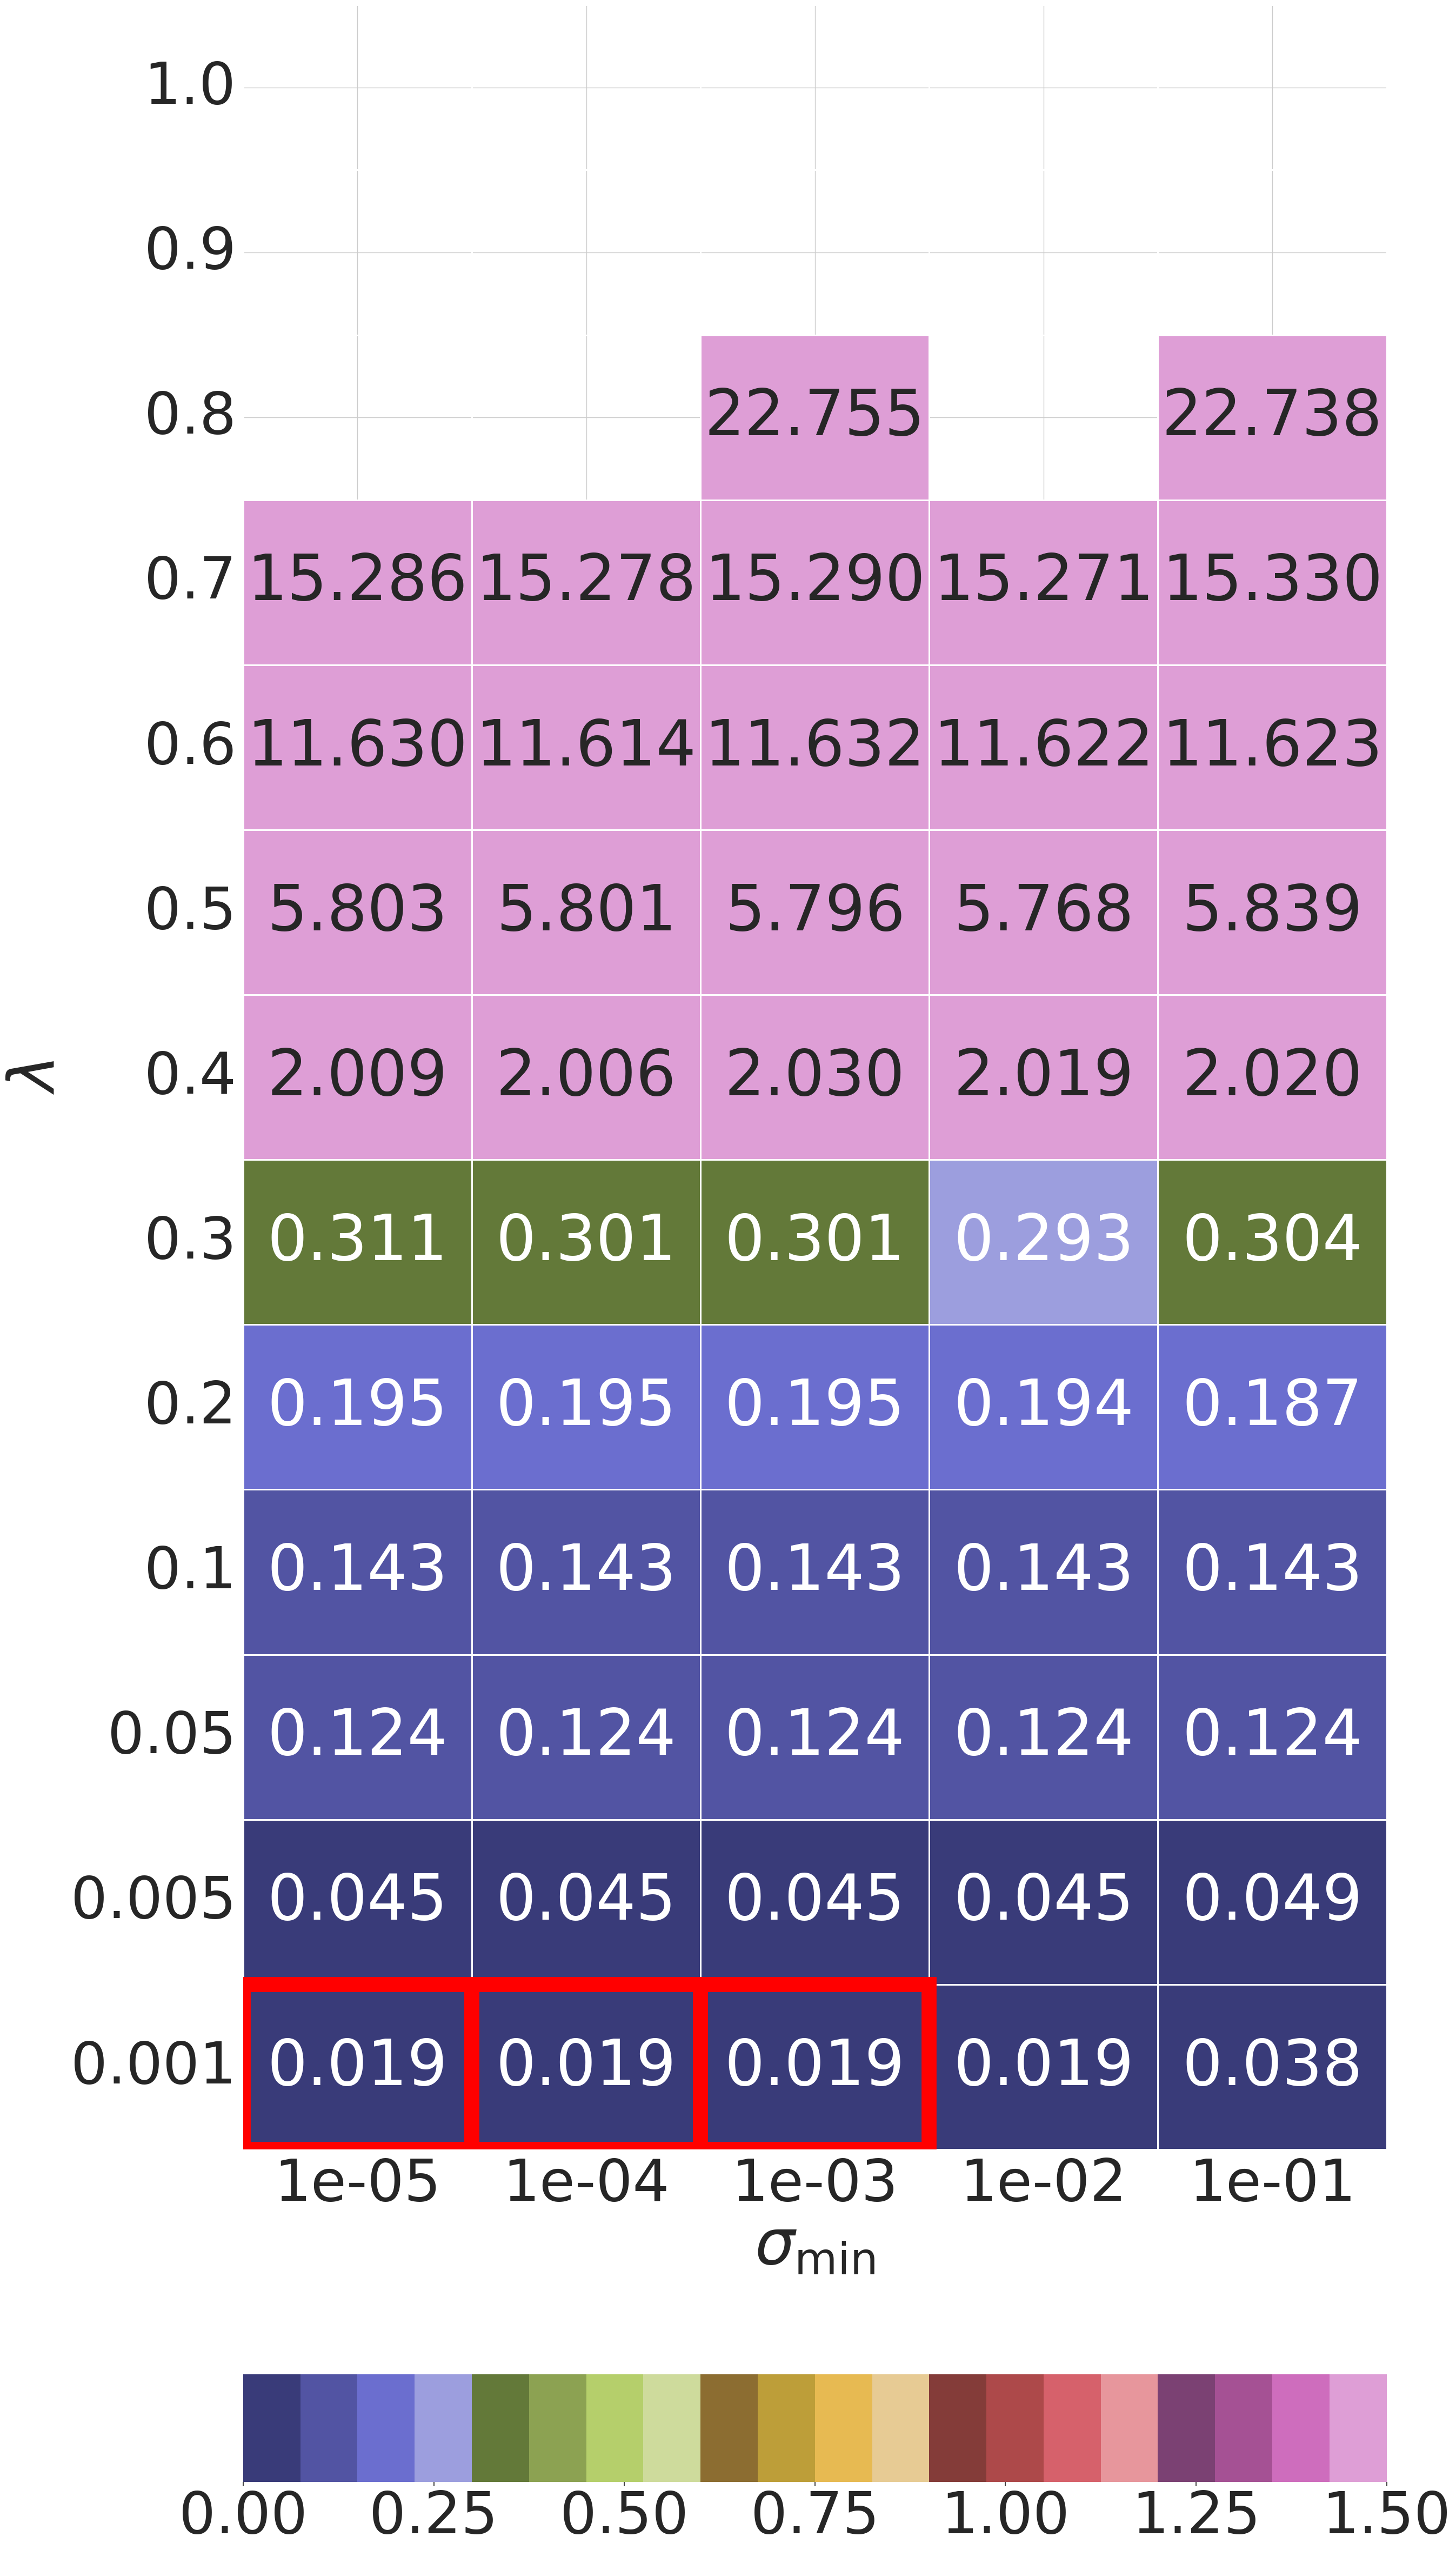

In [461]:
# wscale = 5 + 8
# hscale = 5 + 12
if label == 'EnSF':
    wscale = .8 * font_scale#+ 1
    hscale = 1 * font_scale#+ 4
else:
    wscale = .3 * font_scale
    hscale = 1.7 * font_scale
fig, (ax, ax_cbar) = plt.subplots(2, 1, height_ratios=[20, 1], figsize=(wscale * logged_metrics_pivot.shape[0], hscale * logged_metrics_pivot.shape[1]))
# rmse_max = 5
(
    sns.heatmap(
        data=logged_metrics_pivot,
        linewidths=1,
        annot=True,
        fmt='.3f',
        cmap='tab20b',
        # cmap=cmap,
        vmin=.0,
        vmax=1.5,
        ax=ax,
        cbar_ax=ax_cbar,
        cbar_kws=dict(
            orientation='horizontal',
        ),
    )
)
top_idx_rev = [tuple(reversed(idx)) for idx in top_idx]
for idx in top_idx_rev:
    ax.add_patch(matplotlib.patches.Rectangle(idx, 1, 1, fill=False, edgecolor='red', lw=20))
# ax_cbar.remove()
# ax.invert_xaxis()
ax.invert_yaxis()
fig.savefig(file_dir/f'Tune_{label}_T{sampling_time_step_count}.pdf', format='pdf', bbox_inches='tight', pad_inches=.06)